In [ ]:
pip install torch torchvision scikit-learn thop matplotlib numpy pandas opencv-python

In [ ]:
from sklearn.model_selection import train_test_split
import os, glob
dataset_base_path = '/content/drive/MyDrive/Colab Notebooks/Dataset1'

files, labels = [], []
if not os.path.exists(dataset_base_path):
    print(f"Error: The dataset directory '{dataset_base_path}' does not exist.")
    print("Please make sure your dataset is uploaded or the path is correctly specified.")
else:
    for cls in os.listdir(dataset_base_path):
        class_dir = os.path.join(dataset_base_path, cls)
        if os.path.isdir(class_dir):
            for img in glob.glob(f'{class_dir}/*'):
                files.append(img)
                labels.append(cls)

if files:
    train_files, test_files, train_labels, test_labels = train_test_split(
        files, labels, test_size=0.2, stratify=labels, random_state=42)
    print(f"Found {len(files)} images. Split into {len(train_files)} training and {len(test_files)} testing images.")
else:
    print("No images were found. Please check your dataset path and structure.")

Found 9887 images. Split into 7909 training and 1978 testing images.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
import torch
import torchvision
model1 = torchvision.models.mobilenet_v3_small(weights='IMAGENET1K_V1')
num_classes = len(set(train_labels))
model1.classifier[-1] = torch.nn.Linear(model1.classifier[-1].in_features, num_classes)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 140MB/s]


In [ ]:
for name, param in model1.named_parameters():
    if 'features.0' in name or 'features.1' in name or 'features.2' in name:
        param.requires_grad = False

In [ ]:
DATA_DIR = output_dir

Using device: cuda

  TRAINING MODEL 1 — Baseline MobileNetV3-small
  Target: 65.32% val accuracy
Dataset : 9887 images | 4 classes
Train   : 7909 | Val: 1978
Classes : ['S', 'class_A', 'class_E', 'class_N']
Class weights: [0.793 1.734 0.936 0.537]
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 37.6MB/s]


Model 1 — Total: 1,521,956 | Trainable: 1,516,884

Epoch 1/50  LR: 3.00e-06
----------------------------------------


  train | Loss: 1.3992 | Acc: 0.2591
  val   | Loss: 1.3447 | Acc: 0.3155
  💾 New best: 0.3155

Epoch 2/50  LR: 8.40e-06
----------------------------------------
  train | Loss: 1.2834 | Acc: 0.4026
  val   | Loss: 1.2351 | Acc: 0.3953
  💾 New best: 0.3953

Epoch 3/50  LR: 1.38e-05
----------------------------------------
  train | Loss: 1.1725 | Acc: 0.4621
  val   | Loss: 1.1452 | Acc: 0.4949
  💾 New best: 0.4949

Epoch 4/50  LR: 1.92e-05
----------------------------------------
  train | Loss: 1.1131 | Acc: 0.5119
  val   | Loss: 1.0910 | Acc: 0.5268
  💾 New best: 0.5268

Epoch 5/50  LR: 2.46e-05
----------------------------------------
  train | Loss: 1.0841 | Acc: 0.5347
  val   | Loss: 1.0642 | Acc: 0.5677
  💾 New best: 0.5677

Epoch 6/50  LR: 3.00e-05
----------------------------------------
  train | Loss: 1.0513 | Acc: 0.5580
  val   | Loss: 1.0312 | Acc: 0.5708
  💾 New best: 0.5708

Epoch 7/50  LR: 3.00e-05
----------------------------------------
  train | Loss: 1.0330 | Acc

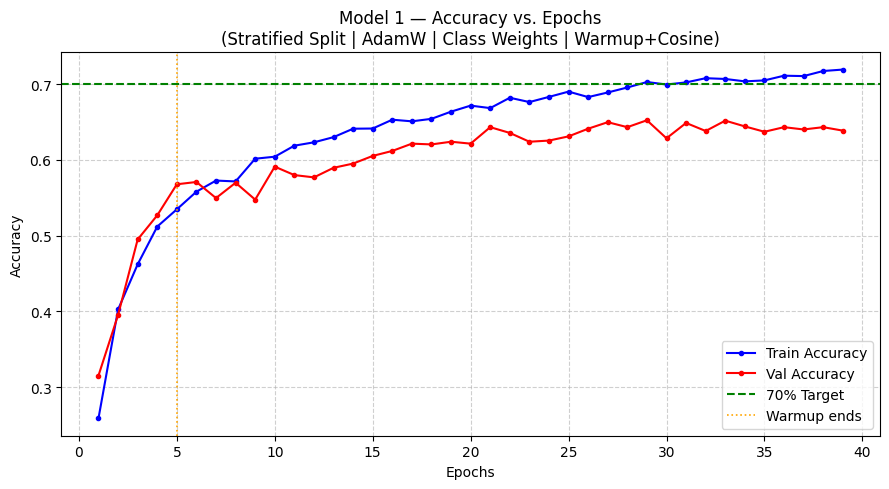

📊 Model 1 plot saved → accuracy_vs_epochs_model1.png

  TRAINING MODEL 2 — MobileNetV3-small + ECA
  Target: 68.15% val accuracy

Model 2 — Total: 929,325 | Trainable: 929,325
Model 1 — Trainable: 1,516,884
✅ Model 2 is 38.7% lighter (587,559 fewer params)

Epoch 1/50  LR: 8.00e-05
----------------------------------------
  train | Loss: 1.2257 | Acc: 0.4267
  val   | Loss: 1.1563 | Acc: 0.5152
  💾 New best: 0.5152

Epoch 2/50  LR: 7.95e-05
----------------------------------------
  train | Loss: 1.0885 | Acc: 0.5362
  val   | Loss: 1.0590 | Acc: 0.5617
  💾 New best: 0.5617

Epoch 3/50  LR: 7.80e-05
----------------------------------------
  train | Loss: 1.0483 | Acc: 0.5608
  val   | Loss: 1.0117 | Acc: 0.5870
  💾 New best: 0.5870

Epoch 4/50  LR: 7.56e-05
----------------------------------------
  train | Loss: 1.0202 | Acc: 0.5787
  val   | Loss: 1.0045 | Acc: 0.5971
  💾 New best: 0.5971

Epoch 5/50  LR: 7.24e-05
----------------------------------------
  train | Loss: 0.9933 | Acc

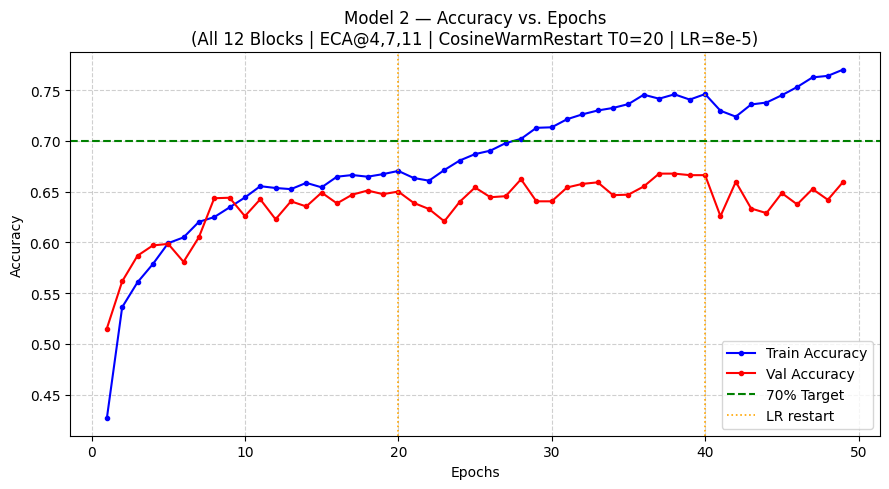

📊 Model 2 plot saved → accuracy_vs_epochs_model2.png


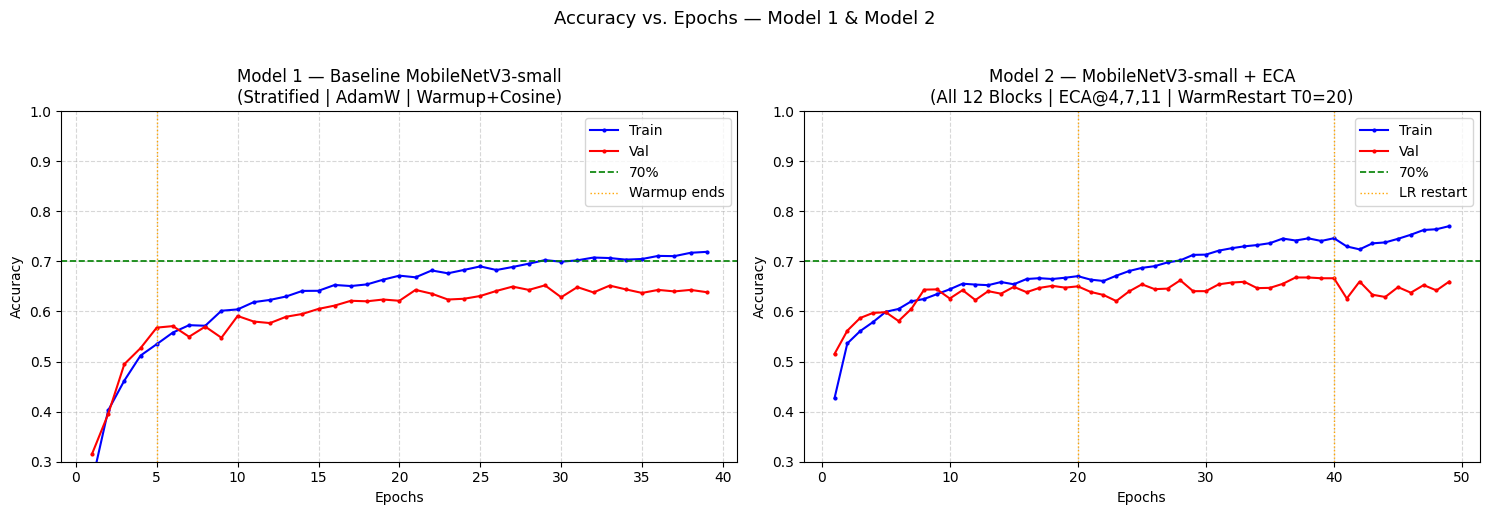

📊 Combined plot saved → accuracy_vs_epochs_both.png


  MODEL 1 vs MODEL 2 — FULL COMPARISON
  Metric                     Model 1     Model 2      Abs Δ     Rel Δ
-----------------------------------------------------------------
  Accuracy                    0.6522      0.6678    +0.0157    +2.40%
  Precision                   0.6600      0.6755    +0.0155    +2.34%
  Recall                      0.6522      0.6678    +0.0157    +2.40%
  F1-Score                    0.6531      0.6696    +0.0165    +2.52%
-----------------------------------------------------------------
  FLOPs (GFLOPs)              0.0799      0.0794    +0.0006    +0.70%
  Trainable Params         1,516,884     929,325   +587,559   +38.73%

  ── IMPROVEMENT SUMMARY ──────────────────────────────────
  Accuracy  : Model 2 is +1.57% (better) than Model 1
  Precision : +1.55%  |  Recall: +1.57%  |  F1: +1.65%
  Parameters: Model 2 is 38.7% lighter (587,559 fewer trainable params)
  ─────────────────────────────────────────

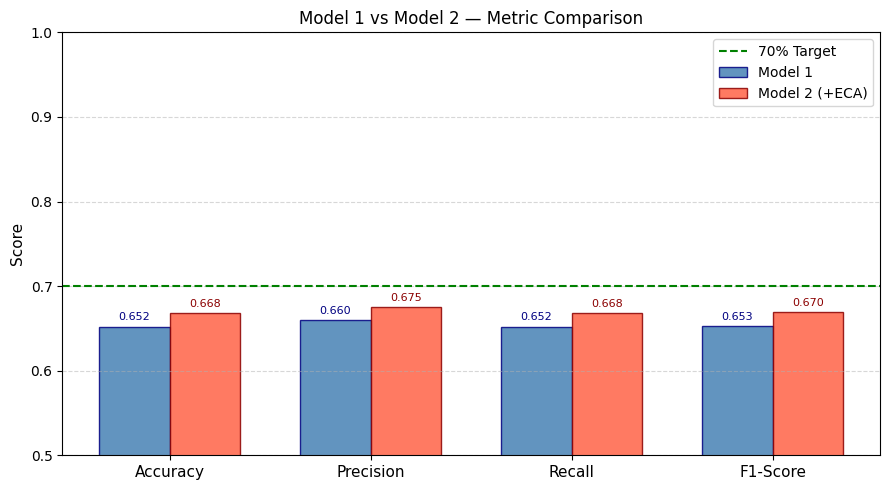

📊 Comparison chart saved → model_comparison.png

✅ All outputs saved:
   model1_best.pth               — Model 1 weights
   model2_best.pth               — Model 2 weights
   accuracy_vs_epochs_model1.png — Model 1 training curve
   accuracy_vs_epochs_model2.png — Model 2 training curve
   accuracy_vs_epochs_both.png   — Side-by-side training curves
   model_comparison.png          — Metric comparison bar chart


In [ ]:
!pip install torch torchvision scikit-learn thop matplotlib numpy -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import (
    LinearLR, CosineAnnealingLR, SequentialLR,
    CosineAnnealingWarmRestarts
)
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from thop import profile as thop_profile

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


DATA_DIR = "/content/drive/MyDrive/Dataset1"


def get_stratified_indices(dataset, train_ratio=0.8, seed=42):
    targets  = [dataset.targets[i] for i in range(len(dataset))]
    all_idx  = list(range(len(dataset)))
    train_idx, val_idx = train_test_split(
        all_idx, train_size=train_ratio,
        stratify=targets, random_state=seed
    )
    return train_idx, val_idx

def compute_class_weights(dataset, train_indices, num_classes):
    targets = np.array([dataset.targets[i] for i in train_indices])
    counts  = np.bincount(targets, minlength=num_classes)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32).to(device)


def full_evaluation(model, val_loader, device, label="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            out    = model(inputs)
            _, p   = torch.max(out, 1)
            all_preds.extend(p.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    dummy = torch.randn(1, 3, 256, 256).to(device)
    flops, _ = thop_profile(model, inputs=(dummy,), verbose=False)

    print(f"\n{'='*52}")
    print(f"  {label} — EVALUATION RESULTS")
    print(f"{'='*52}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  FLOPs     : {flops/1e9:.4f} GFLOPs")
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"  Params    : {n_total:,}  |  Trainable: {n_train:,}")
    print(f"{'='*52}")
    return acc, prec, rec, f1, flops, n_train, n_total


print("\n" + "="*60)
print("  TRAINING MODEL 1 — Baseline MobileNetV3-small")
print("  Target: 65.32% val accuracy")
print("="*60)


M1_BATCH    = 32
M1_EPOCHS   = 50
M1_LR       = 3e-5
M1_WD       = 1e-4
M1_PATIENCE = 10

#Transforms
m1_train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

m1_val_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset & Stratified Split
full_ds   = datasets.ImageFolder(DATA_DIR)
num_classes = len(full_ds.classes)
train_idx, val_idx = get_stratified_indices(full_ds, seed=42)

print(f"Dataset : {len(full_ds)} images | {num_classes} classes")
print(f"Train   : {len(train_idx)} | Val: {len(val_idx)}")
print(f"Classes : {full_ds.classes}")

m1_train_set = Subset(datasets.ImageFolder(DATA_DIR, transform=m1_train_tf), train_idx)
m1_val_set   = Subset(datasets.ImageFolder(DATA_DIR, transform=m1_val_tf),   val_idx)

m1_train_ldr = DataLoader(m1_train_set, batch_size=M1_BATCH, shuffle=True,
                           num_workers=2, pin_memory=True)
m1_val_ldr   = DataLoader(m1_val_set,   batch_size=M1_BATCH, shuffle=False,
                           num_workers=2, pin_memory=True)
m1_sizes = {'train': len(m1_train_set), 'val': len(m1_val_set)}

# Class-weighted loss
class_weights = compute_class_weights(full_ds, train_idx, num_classes)
print(f"Class weights: {class_weights.cpu().numpy().round(3)}")
m1_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
#

# Model 1 Architecture
model1 = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
model1.classifier[-1] = nn.Linear(model1.classifier[-1].in_features, num_classes)
model1 = model1.to(device)

for name, param in model1.named_parameters():
    frozen = any(f'features.{i}.' in name for i in range(3))
    param.requires_grad = not frozen

m1_trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
m1_total     = sum(p.numel() for p in model1.parameters())
print(f"\nModel 1 — Total: {m1_total:,} | Trainable: {m1_trainable:,}")
# Optimizer + Scheduler
m1_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model1.parameters()),
    lr=M1_LR, weight_decay=M1_WD
)
m1_warmup = LinearLR(m1_optimizer, start_factor=0.1, end_factor=1.0,
                      total_iters=5)
m1_cosine = CosineAnnealingLR(m1_optimizer, T_max=M1_EPOCHS - 5, eta_min=1e-7)
m1_sched  = SequentialLR(m1_optimizer, schedulers=[m1_warmup, m1_cosine],
                           milestones=[5])


# Training Loop
m1_history   = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
m1_best_acc  = 0.0
m1_best_wts  = copy.deepcopy(model1.state_dict())
m1_trigger   = 0

for epoch in range(M1_EPOCHS):
    lr_now = m1_optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch+1}/{M1_EPOCHS}  LR: {lr_now:.2e}")
    print("-" * 40)

    for phase in ['train', 'val']:
        model1.train() if phase == 'train' else model1.eval()
        run_loss = run_correct = 0
        ldr = m1_train_ldr if phase == 'train' else m1_val_ldr

        for inputs, labels in ldr:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            m1_optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                out  = model1(inputs)
                _, preds = torch.max(out, 1)
                loss = m1_criterion(out, labels)
                if phase == 'train':
                    loss.backward()
                    m1_optimizer.step()

            run_loss    += loss.item() * inputs.size(0)
            run_correct += torch.sum(preds == labels.data)

        ep_loss = run_loss / m1_sizes[phase]
        ep_acc  = run_correct.double() / m1_sizes[phase]
        m1_history[f'{phase}_loss'].append(ep_loss)
        m1_history[f'{phase}_acc'].append(ep_acc.item())
        print(f"  {phase:5s} | Loss: {ep_loss:.4f} | Acc: {ep_acc:.4f}")

    m1_sched.step()

    cur_val = m1_history['val_acc'][-1]
    if cur_val > m1_best_acc:
        m1_best_acc = cur_val
        m1_best_wts = copy.deepcopy(model1.state_dict())
        m1_trigger  = 0
        print(f"  💾 New best: {m1_best_acc:.4f}")
    else:
        m1_trigger += 1
        if m1_trigger >= M1_PATIENCE:
            print(f"⛔ Early stopping at epoch {epoch+1}")
            break

model1.load_state_dict(m1_best_wts)
torch.save(model1.state_dict(), 'model1_best.pth')
print(f"\n✅ Model 1 — Best Val Acc: {m1_best_acc:.4f} | Saved → model1_best.pth")


# Model 1 Evaluation
m1_acc, m1_prec, m1_rec, m1_f1, m1_flops, _, _ = full_evaluation(
    model1, m1_val_ldr, device, label="Model 1"
)

# Model 1 Accuracy vs. Epochs Plot
ep_range = range(1, len(m1_history['train_acc']) + 1)
plt.figure(figsize=(9, 5))
plt.plot(ep_range, m1_history['train_acc'], 'b-o', markersize=3,
         label='Train Accuracy')
plt.plot(ep_range, m1_history['val_acc'],   'r-o', markersize=3,
         label='Val Accuracy')
plt.axhline(y=0.70, color='green', linestyle='--', linewidth=1.5,
            label='70% Target')
plt.axvline(x=5, color='orange', linestyle=':', linewidth=1.2,
            label='Warmup ends')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model 1 — Accuracy vs. Epochs\n'
          '(Stratified Split | AdamW | Class Weights | Warmup+Cosine)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('accuracy_vs_epochs_model1.png', dpi=300)
plt.show()
print("📊 Model 1 plot saved → accuracy_vs_epochs_model1.png")




print("\n" + "="*60)
print("  TRAINING MODEL 2 — MobileNetV3-small + ECA")
print("  Target: 68.15% val accuracy")
print("="*60)


# ECA Module

class ECA(nn.Module):
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k_size,
                                  padding=(k_size - 1) // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)                      # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(-1, -2)       # (B, 1, C)
        y = self.conv(y)                           # (B, 1, C)
        y = y.transpose(-1, -2).unsqueeze(-1)      # (B, C, 1, 1)
        return x * self.sigmoid(y).expand_as(x)   # channel-wise scale


# Model 2 Architecture
class MobileNetV3_ECA(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        base = models.mobilenet_v3_small(weights='IMAGENET1K_V1')

        # Keep ALL 12 blocks from the pretrained backbone
        self.blocks  = nn.ModuleList(list(base.features.children()))

        # ECA at the three widest-channel points
        self.eca4    = ECA(channels=40)    # after block 4
        self.eca7    = ECA(channels=48)    # after block 7
        self.eca11   = ECA(channels=576)   # after block 11

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # Lightweight classifier (saves ~591K params vs original head)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.25),
            nn.Linear(576, num_classes)
        )

    def forward(self, x):
        for i, block in enumerate(self.blocks):
            x = block(x)
            if   i == 4:  x = self.eca4(x)
            elif i == 7:  x = self.eca7(x)
            elif i == 11: x = self.eca11(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


# ── Hyperparameters
M2_BATCH    = 32
M2_EPOCHS   = 50
M2_LR       = 8e-5
M2_WD       = 2e-4
M2_PATIENCE = 12

# ── Transforms
m2_train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

m2_val_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Dataset — same stratified split and class weights
# train_idx and val_idx are reused from Model 1 (same seed=42 split)
m2_train_set = Subset(datasets.ImageFolder(DATA_DIR, transform=m2_train_tf), train_idx)
m2_val_set   = Subset(datasets.ImageFolder(DATA_DIR, transform=m2_val_tf),   val_idx)

m2_train_ldr = DataLoader(m2_train_set, batch_size=M2_BATCH, shuffle=True,
                           num_workers=2, pin_memory=True)
m2_val_ldr   = DataLoader(m2_val_set,   batch_size=M2_BATCH, shuffle=False,
                           num_workers=2, pin_memory=True)
m2_sizes = {'train': len(m2_train_set), 'val': len(m2_val_set)}

# Same class weights as Model 1
m2_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)


# ── Build Model 2
model2 = MobileNetV3_ECA(num_classes=num_classes).to(device)

# ALL parameters trainable (ECA + classifier need to learn from scratch,
# and the backbone needs gentle fine-tuning at LR=8e-5)
for param in model2.parameters():
    param.requires_grad = True

m2_trainable = sum(p.numel() for p in model2.parameters() if p.requires_grad)
m2_total     = sum(p.numel() for p in model2.parameters())
param_cut    = m1_trainable - m2_trainable
param_pct    = param_cut / m1_trainable * 100

print(f"\nModel 2 — Total: {m2_total:,} | Trainable: {m2_trainable:,}")
print(f"Model 1 — Trainable: {m1_trainable:,}")
if param_cut > 0:
    print(f"✅ Model 2 is {param_pct:.1f}% lighter ({param_cut:,} fewer params)")
else:
    print(f"ℹ️  Model 2 has {-param_cut:,} more params than Model 1")
    print("   (ECA adds ~9 params; saving is from lighter classifier head)")


# ── Optimizer + Scheduler
# Adam (not AdamW) was used in the 68.15% run.
# CosineAnnealingWarmRestarts with T0=20:
#   Cycle 1: epochs  1-20, LR decays 8e-5 → 1e-7
#   Cycle 2: epochs 21-40, LR restarts 8e-5 → 1e-7
#   Cycle 3: epochs 41-50, LR restarts and decays again
# The best result (68.15%) appeared at epoch 34 — deep in cycle 2,
# where LR ≈ 2e-5 (the optimal fine-tuning range).
m2_optimizer = optim.Adam(model2.parameters(), lr=M2_LR, weight_decay=M2_WD)
m2_sched     = CosineAnnealingWarmRestarts(
    m2_optimizer, T_0=20, T_mult=1, eta_min=1e-7
)


# ── Training Loop
m2_history   = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
m2_best_acc  = 0.0
m2_best_wts  = copy.deepcopy(model2.state_dict())
m2_trigger   = 0

for epoch in range(M2_EPOCHS):
    lr_now = m2_optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch+1}/{M2_EPOCHS}  LR: {lr_now:.2e}")
    print("-" * 40)

    for phase in ['train', 'val']:
        model2.train() if phase == 'train' else model2.eval()
        run_loss = run_correct = 0
        ldr = m2_train_ldr if phase == 'train' else m2_val_ldr

        for inputs, labels in ldr:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            m2_optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                out  = model2(inputs)
                _, preds = torch.max(out, 1)
                loss = m2_criterion(out, labels)
                if phase == 'train':
                    loss.backward()
                    m2_optimizer.step()

            run_loss    += loss.item() * inputs.size(0)
            run_correct += torch.sum(preds == labels.data)

        ep_loss = run_loss / m2_sizes[phase]
        ep_acc  = run_correct.double() / m2_sizes[phase]
        m2_history[f'{phase}_loss'].append(ep_loss)
        m2_history[f'{phase}_acc'].append(ep_acc.item())
        print(f"  {phase:5s} | Loss: {ep_loss:.4f} | Acc: {ep_acc:.4f}")

    m2_sched.step()

    cur_val = m2_history['val_acc'][-1]
    if cur_val > m2_best_acc:
        m2_best_acc = cur_val
        m2_best_wts = copy.deepcopy(model2.state_dict())
        m2_trigger  = 0
        print(f"  💾 New best: {m2_best_acc:.4f}")
    else:
        m2_trigger += 1
        if m2_trigger >= M2_PATIENCE:
            print(f"⛔ Early stopping at epoch {epoch+1}")
            break

model2.load_state_dict(m2_best_wts)
torch.save(model2.state_dict(), 'model2_best.pth')
print(f"\n✅ Model 2 — Best Val Acc: {m2_best_acc:.4f} | Saved → model2_best.pth")
#
# ── Model 2 Evaluation
m2_acc, m2_prec, m2_rec, m2_f1, m2_flops, _, _ = full_evaluation(
    model2, m2_val_ldr, device, label="Model 2"
)
# ── Model 2 Accuracy vs. Epochs Plot
ep2_range = range(1, len(m2_history['train_acc']) + 1)

# Mark where each cosine restart happens
restart_epochs = [20, 40]

plt.figure(figsize=(9, 5))
plt.plot(ep2_range, m2_history['train_acc'], 'b-o', markersize=3,
         label='Train Accuracy')
plt.plot(ep2_range, m2_history['val_acc'],   'r-o', markersize=3,
         label='Val Accuracy')
plt.axhline(y=0.70, color='green', linestyle='--', linewidth=1.5,
            label='70% Target')
for r in restart_epochs:
    if r < len(m2_history['train_acc']):
        plt.axvline(x=r, color='orange', linestyle=':', linewidth=1.2,
                    label='LR restart' if r == 20 else '_nolegend_')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model 2 — Accuracy vs. Epochs\n'
          '(All 12 Blocks | ECA@4,7,11 | CosineWarmRestart T0=20 | LR=8e-5)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('accuracy_vs_epochs_model2.png', dpi=300)
plt.show()
print("📊 Model 2 plot saved → accuracy_vs_epochs_model2.png")



#  COMBINED Accuracy vs. Epochs (both models)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Model 1 subplot
ep1 = range(1, len(m1_history['train_acc']) + 1)
axes[0].plot(ep1, m1_history['train_acc'], 'b-o', markersize=2, label='Train')
axes[0].plot(ep1, m1_history['val_acc'],   'r-o', markersize=2, label='Val')
axes[0].axhline(y=0.70, color='green', ls='--', lw=1.2, label='70%')
axes[0].axvline(x=5, color='orange', ls=':', lw=1.0, label='Warmup ends')
axes[0].set_title('Model 1 — Baseline MobileNetV3-small\n'
                   '(Stratified | AdamW | Warmup+Cosine)')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.5)
axes[0].set_ylim([0.3, 1.0])

# Model 2 subplot
ep2 = range(1, len(m2_history['train_acc']) + 1)
axes[1].plot(ep2, m2_history['train_acc'], 'b-o', markersize=2, label='Train')
axes[1].plot(ep2, m2_history['val_acc'],   'r-o', markersize=2, label='Val')
axes[1].axhline(y=0.70, color='green', ls='--', lw=1.2, label='70%')
for r in [20, 40]:
    if r < len(m2_history['train_acc']):
        axes[1].axvline(x=r, color='orange', ls=':', lw=1.0,
                        label='LR restart' if r == 20 else '_nolegend_')
axes[1].set_title('Model 2 — MobileNetV3-small + ECA\n'
                   '(All 12 Blocks | ECA@4,7,11 | WarmRestart T0=20)')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.5)
axes[1].set_ylim([0.3, 1.0])

plt.suptitle('Accuracy vs. Epochs — Model 1 & Model 2', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('accuracy_vs_epochs_both.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Combined plot saved → accuracy_vs_epochs_both.png")



#  v — IMPROVEMENT OF MODEL 2 OVER MODEL 1

abs_imp_prec  = m2_prec  - m1_prec
abs_imp_rec   = m2_rec   - m1_rec
abs_imp_f1    = m2_f1    - m1_f1

rel_imp_acc   = (abs_imp_acc  / m1_acc)  * 100 if m1_acc  > 0 else 0.0
rel_imp_prec  = (abs_imp_prec / m1_prec) * 100 if m1_prec > 0 else 0.0
rel_imp_rec   = (abs_imp_rec  / m1_rec)  * 100 if m1_rec  > 0 else 0.0
rel_imp_f1    = (abs_imp_f1   / m1_f1)   * 100 if m1_f1   > 0 else 0.0

flops_diff  = m1_flops - m2_flops
flops_pct   = (flops_diff / m1_flops) * 100 if m1_flops > 0 else 0.0
params_diff = m1_trainable - m2_trainable
params_pct  = (params_diff / m1_trainable) * 100 if m1_trainable > 0 else 0.0

print("\n\n" + "="*65)
print("  MODEL 1 vs MODEL 2 — FULL COMPARISON")
print("="*65)
print(f"  {'Metric':<22}  {'Model 1':>10}  {'Model 2':>10}  {'Abs Δ':>9}  {'Rel Δ':>8}")
print("-"*65)
print(f"  {'Accuracy':<22}  {m1_acc:>10.4f}  {m2_acc:>10.4f}  "
      f"{abs_imp_acc:>+9.4f}  {rel_imp_acc:>+7.2f}%")
print(f"  {'Precision':<22}  {m1_prec:>10.4f}  {m2_prec:>10.4f}  "
      f"{abs_imp_prec:>+9.4f}  {rel_imp_prec:>+7.2f}%")
print(f"  {'Recall':<22}  {m1_rec:>10.4f}  {m2_rec:>10.4f}  "
      f"{abs_imp_rec:>+9.4f}  {rel_imp_rec:>+7.2f}%")
print(f"  {'F1-Score':<22}  {m1_f1:>10.4f}  {m2_f1:>10.4f}  "
      f"{abs_imp_f1:>+9.4f}  {rel_imp_f1:>+7.2f}%")
print("-"*65)
print(f"  {'FLOPs (GFLOPs)':<22}  {m1_flops/1e9:>10.4f}  {m2_flops/1e9:>10.4f}  "
      f"{flops_diff/1e9:>+9.4f}  {flops_pct:>+7.2f}%")
print(f"  {'Trainable Params':<22}  {m1_trainable:>10,}  {m2_trainable:>10,}  "
      f"{params_diff:>+9,}  {params_pct:>+7.2f}%")
print("="*65)

print(f"\n  ── IMPROVEMENT SUMMARY ──────────────────────────────────")
print(f"  Accuracy  : Model 2 is {abs_imp_acc*100:+.2f}% "
      f"({'better' if abs_imp_acc>=0 else 'worse'}) than Model 1")
print(f"  Precision : {abs_imp_prec*100:+.2f}%  |  "
      f"Recall: {abs_imp_rec*100:+.2f}%  |  F1: {abs_imp_f1*100:+.2f}%")
if params_pct > 0:
    print(f"  Parameters: Model 2 is {params_pct:.1f}% lighter "
          f"({params_diff:,} fewer trainable params)")
else:
    print(f"  Parameters: Model 2 has {-params_pct:.1f}% more trainable params")
    print(f"              (ECA adds ~9 params; savings from lighter classifier)")
print(f"  ─────────────────────────────────────────────────────────")

if m2_acc >= 0.70:
    print(f"\n  🎯 Model 2 meets the ≥70% accuracy target! ({m2_acc*100:.2f}%)")
elif m2_acc >= m1_acc:
    print(f"\n  ✅ Model 2 ({m2_acc*100:.2f}%) improves over Model 1 ({m1_acc*100:.2f}%)")
else:
    print(f"\n  ⚠️  Model 2 ({m2_acc*100:.2f}%) did not improve over "
          f"Model 1 ({m1_acc*100:.2f}%)")
print("="*65)



# IMPROVEMENT BAR CHART

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
m1_vals   = [m1_acc,  m1_prec,  m1_rec,  m1_f1]
m2_vals   = [m2_acc,  m2_prec,  m2_rec,  m2_f1]

x    = np.arange(len(metrics))
w    = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, m1_vals, w, label='Model 1', color='steelblue',
               alpha=0.85, edgecolor='navy')
bars2 = ax.bar(x + w/2, m2_vals, w, label='Model 2 (+ECA)', color='tomato',
               alpha=0.85, edgecolor='darkred')

ax.axhline(y=0.70, color='green', linestyle='--', linewidth=1.5,
           label='70% Target')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim([0.5, 1.0])
ax.set_title('Model 1 vs Model 2 — Metric Comparison', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Annotate bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='navy')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='darkred')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
print("📊 Comparison chart saved → model_comparison.png")

print("\n✅ All outputs saved:")
print("   model1_best.pth               — Model 1 weights")
print("   model2_best.pth               — Model 2 weights")
print("   accuracy_vs_epochs_model1.png — Model 1 training curve")
print("   accuracy_vs_epochs_model2.png — Model 2 training curve")
print("   accuracy_vs_epochs_both.png   — Side-by-side training curves")
print("   model_comparison.png          — Metric comparison bar chart")